In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress

In [26]:
def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

def linear_model(x, m):
    return m * x

In [27]:
data = pd.read_csv("data/kinetics_results.csv", sep=";")

In [28]:
proteins = data["Protein"].unique()  #["WT", "S166A", "Quad", "H191E", "H32L", "G37D", "K237R"]
substrate = data["SAM Conc"].unique()
timepoints = data["Timepoint"].unique()
replicates = data["Replicate"].unique()

index = pd.MultiIndex.from_product(
    [proteins, substrate, replicates],
    names=["Protein", "SAM Conc", "Replicate"]
)

# Convert to DataFrame
slopes = index.to_frame(index=False)

slopes["v0"] = 0
# slopes["v0_stderr"] = 0
# slopes["R2"] = 0

In [29]:
for prot in proteins:
    for S in substrate: 
        for rep in replicates:
            
            subset = data.loc[(data["Protein"]==prot) & (data["SAM Conc"]==S) & (data["Replicate"]==rep)]   ### Add to exclude values with >20% conversion: & (data["FDA used"]<20)
            
            t_data = np.array(subset["Timepoint"])
            P_data = np.array(subset["FDA Conc"]) 
            
            slope_opt, _ = curve_fit(linear_model, t_data, P_data)
            
            # slope, intercept, r_value, p_value, std_err = linregress(t_data, P_data)
            # print(slope_opt)
            
            slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "v0"] = slope_opt[0]
            # slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "v0_stderr"] = std_err
            # slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "R2"] = r_value

/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_10290/3066319733.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0680612752769232' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "v0"] = slope_opt[0]


In [156]:
data["SAM Conc"].unique()

array([400.  , 181.82,  82.65,  37.57,  17.08,   7.76,   3.53,   1.6 ])

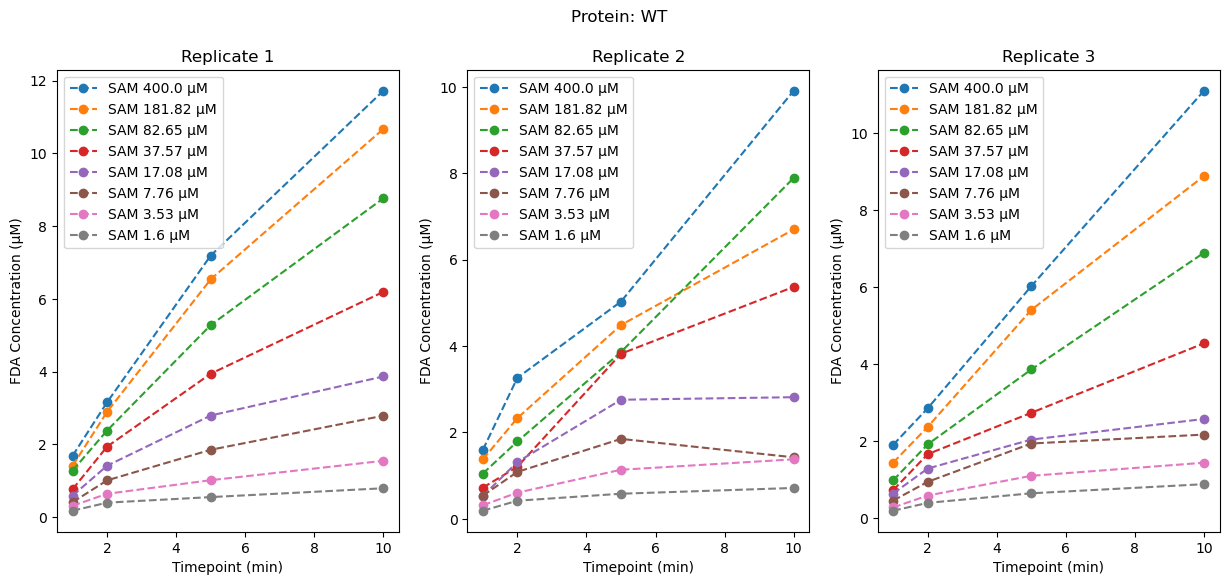

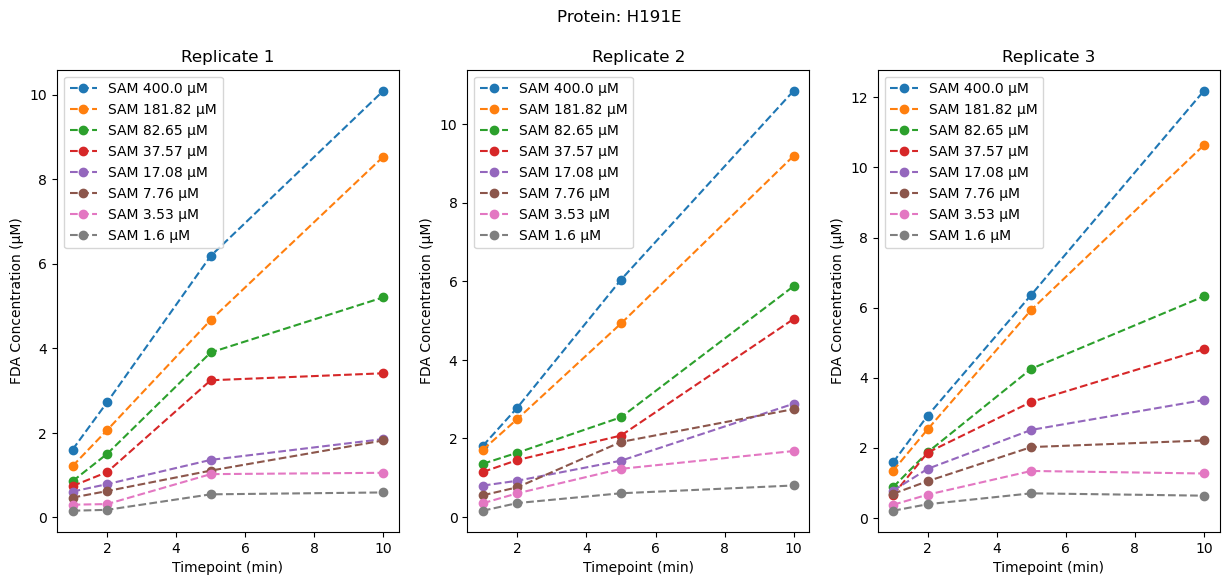

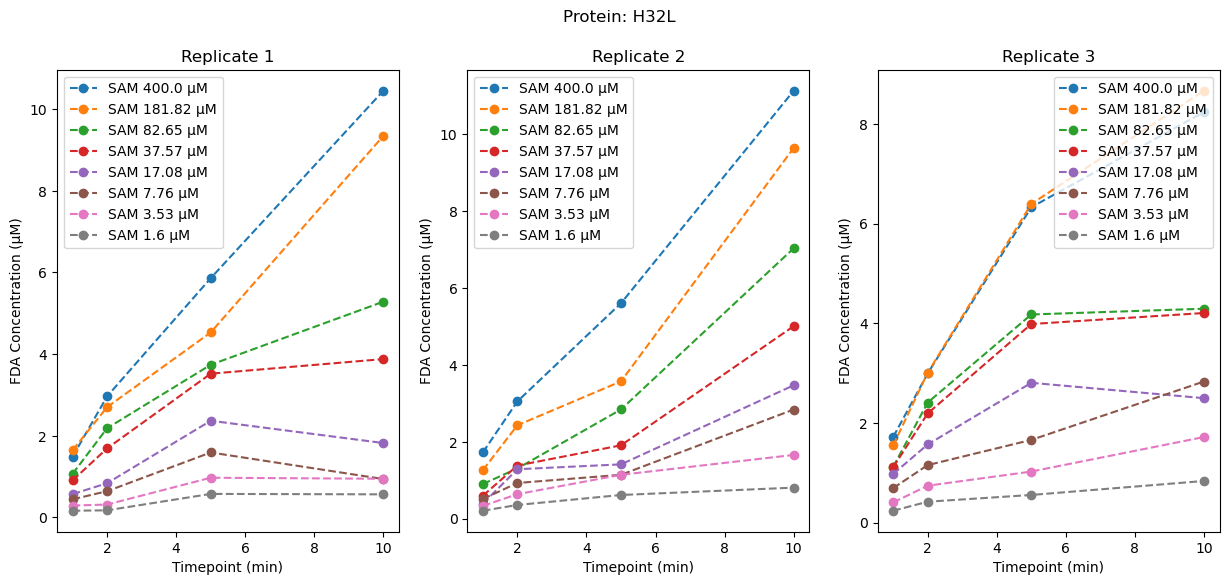

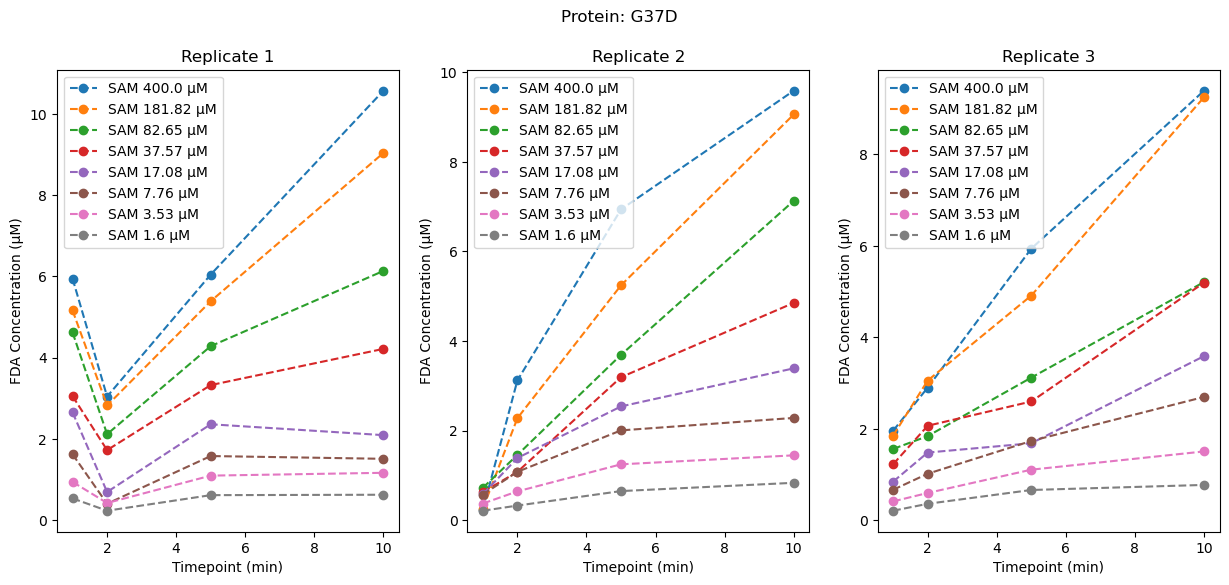

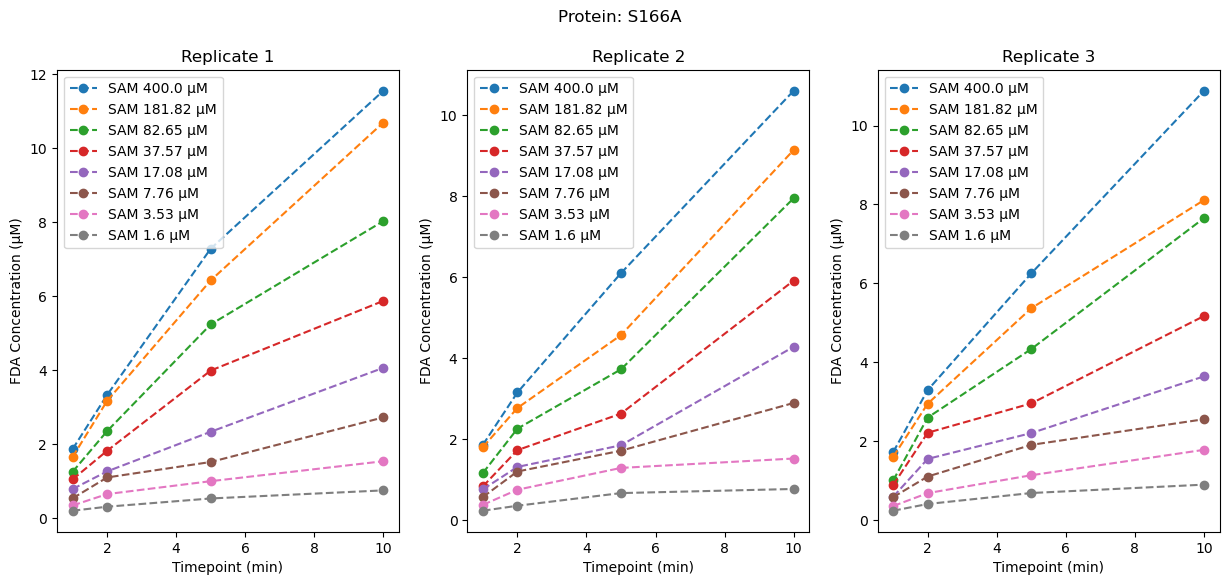

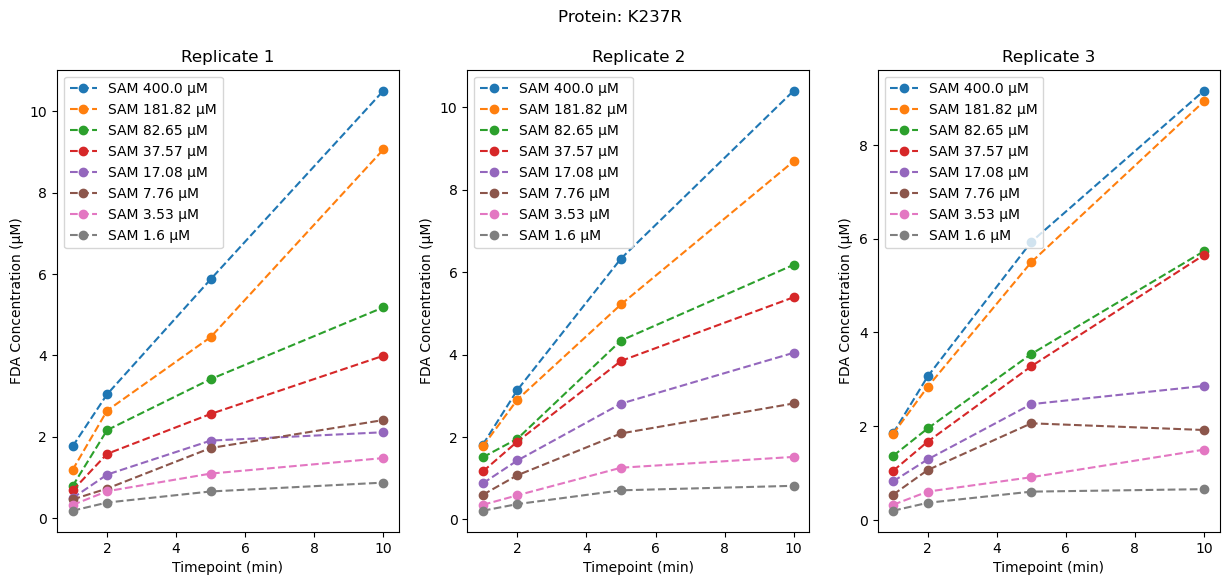

In [167]:
protein_order = ["WT", "H191E", "H32L", "G37D", "S166A", "K237R"]
for prot in protein_order:
    fig,axes = plt.subplots(ncols=3, figsize=(15, 6))
    for i,ax in enumerate(axes):
        for conc in data["SAM Conc"].unique():
            subset = data.loc[(data["Protein"]==prot) & (data["SAM Conc"]==conc) & (data["Replicate"]==i+1)]
            ax.plot(subset["Timepoint"], subset["FDA Conc"], 'o',label=f'SAM {conc} µM',ls='--')
        ax.set_xlabel('Timepoint (min)')
        ax.set_ylabel('FDA Concentration (µM)')
        ax.legend()
        ax.set_title(f'Replicate {i+1}')
    fig.suptitle(f'Protein: {prot}')
    plt.show()

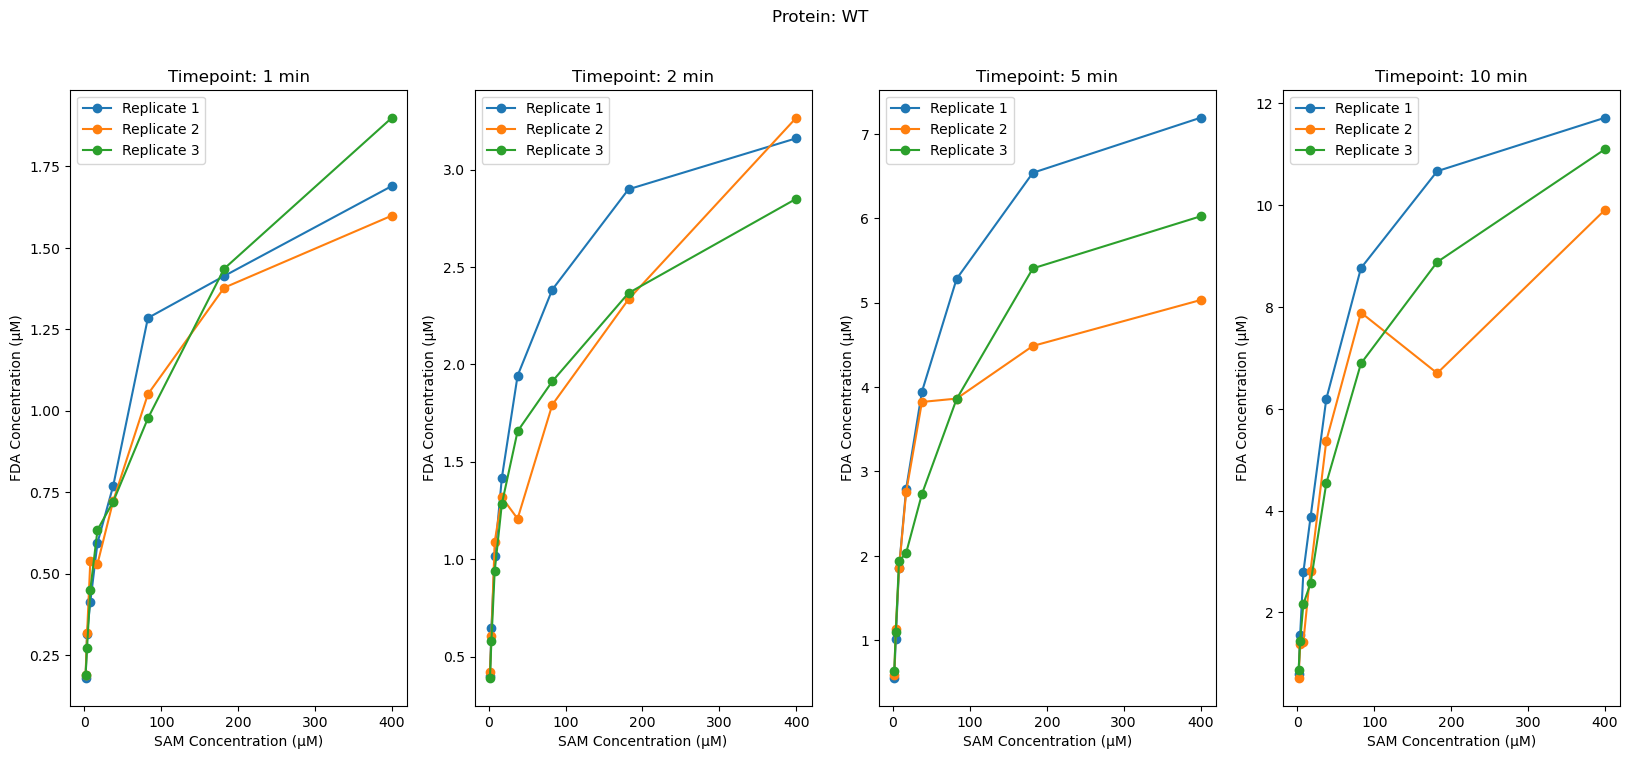

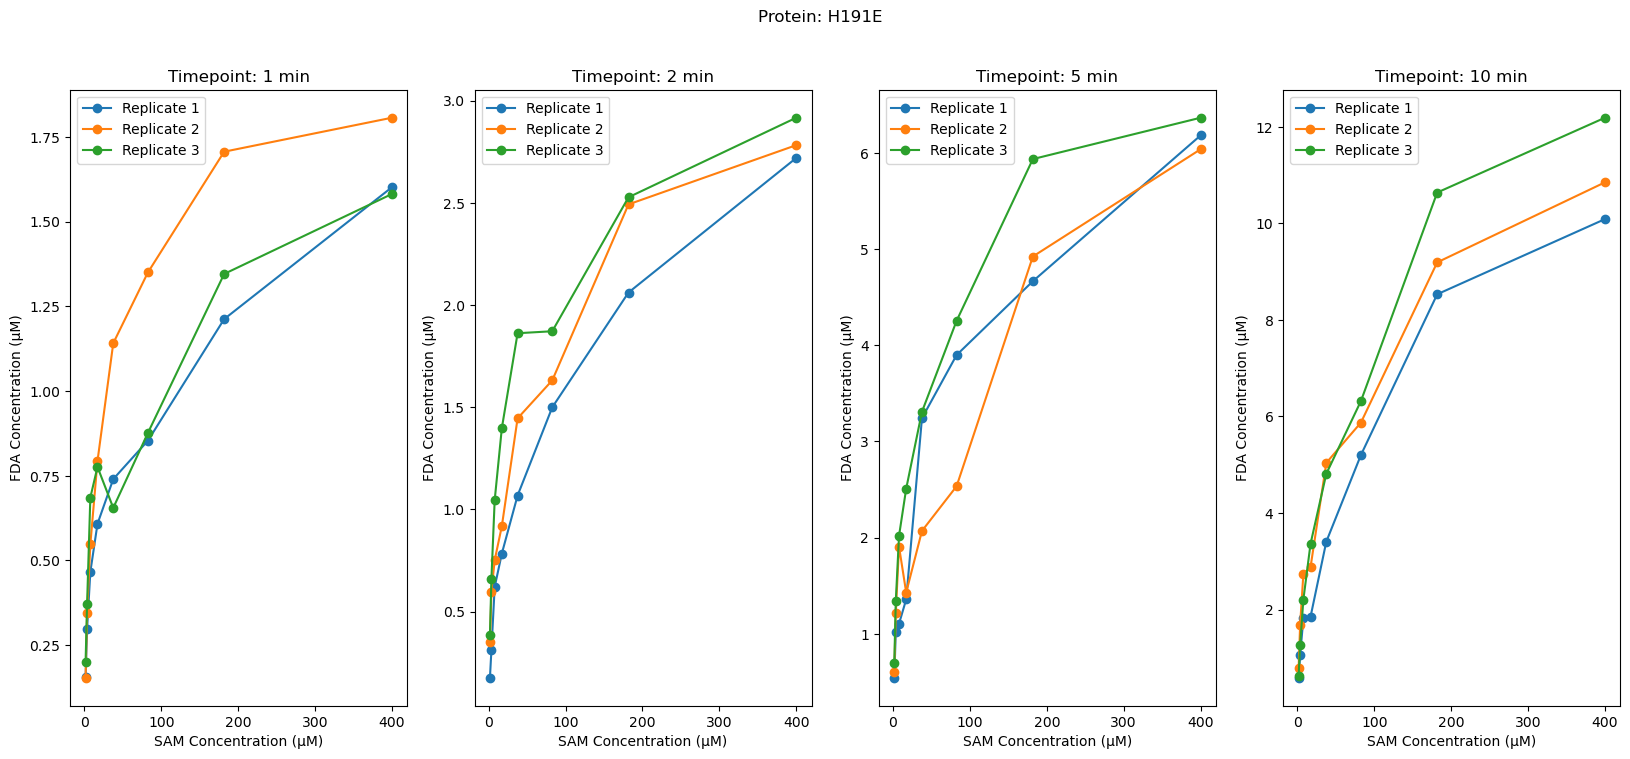

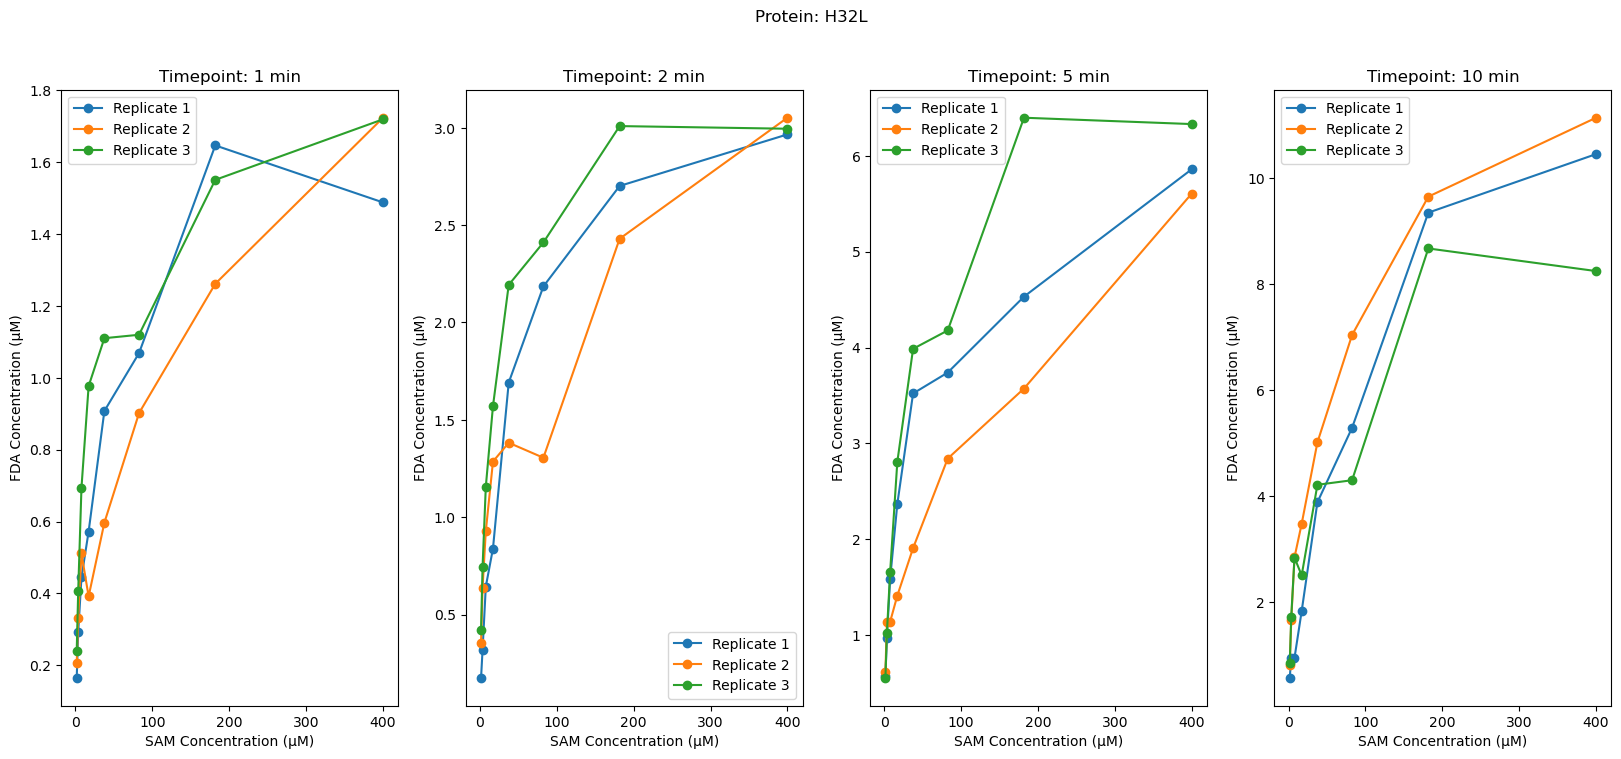

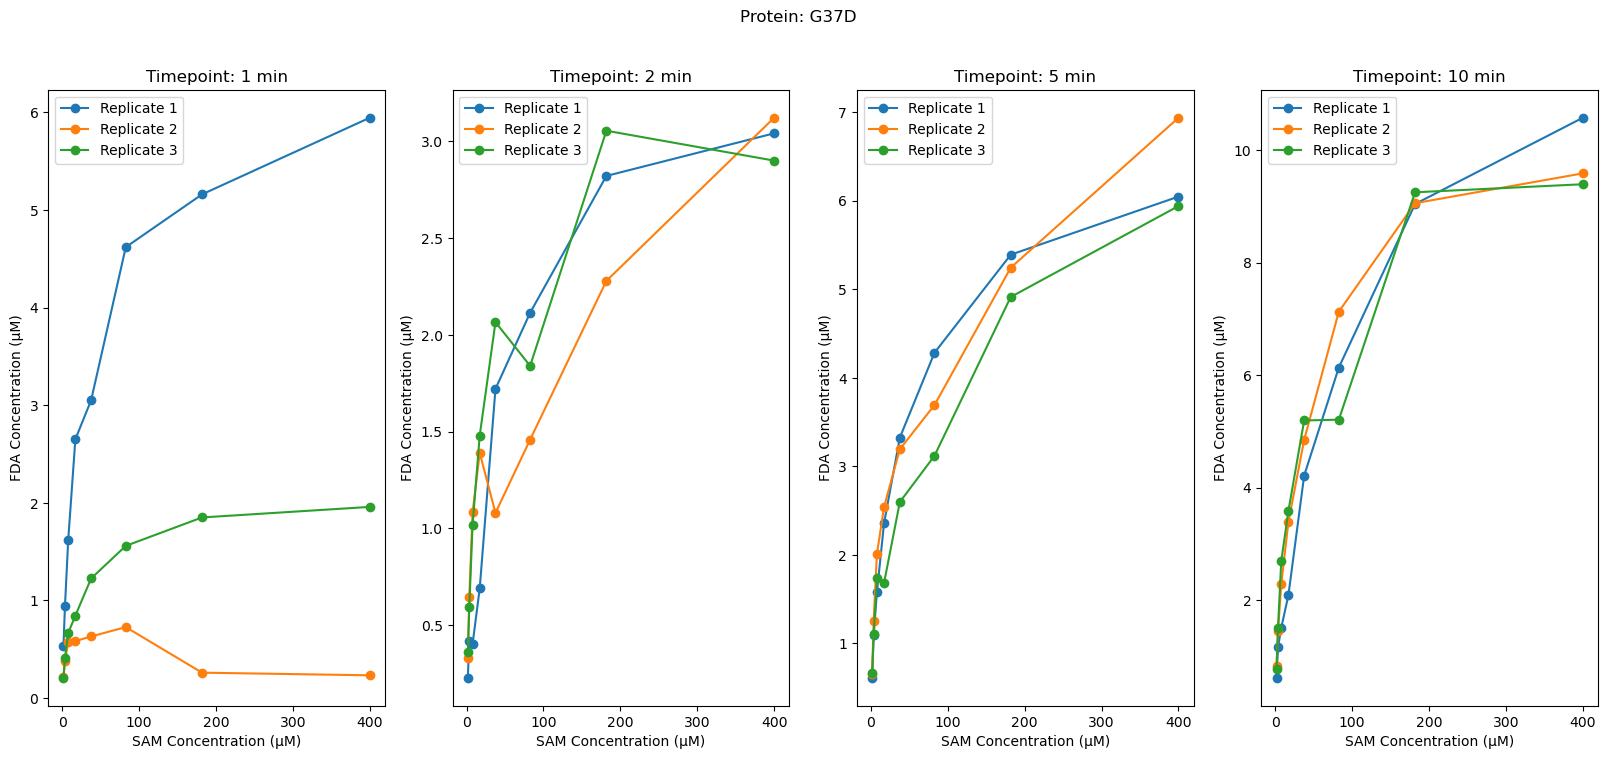

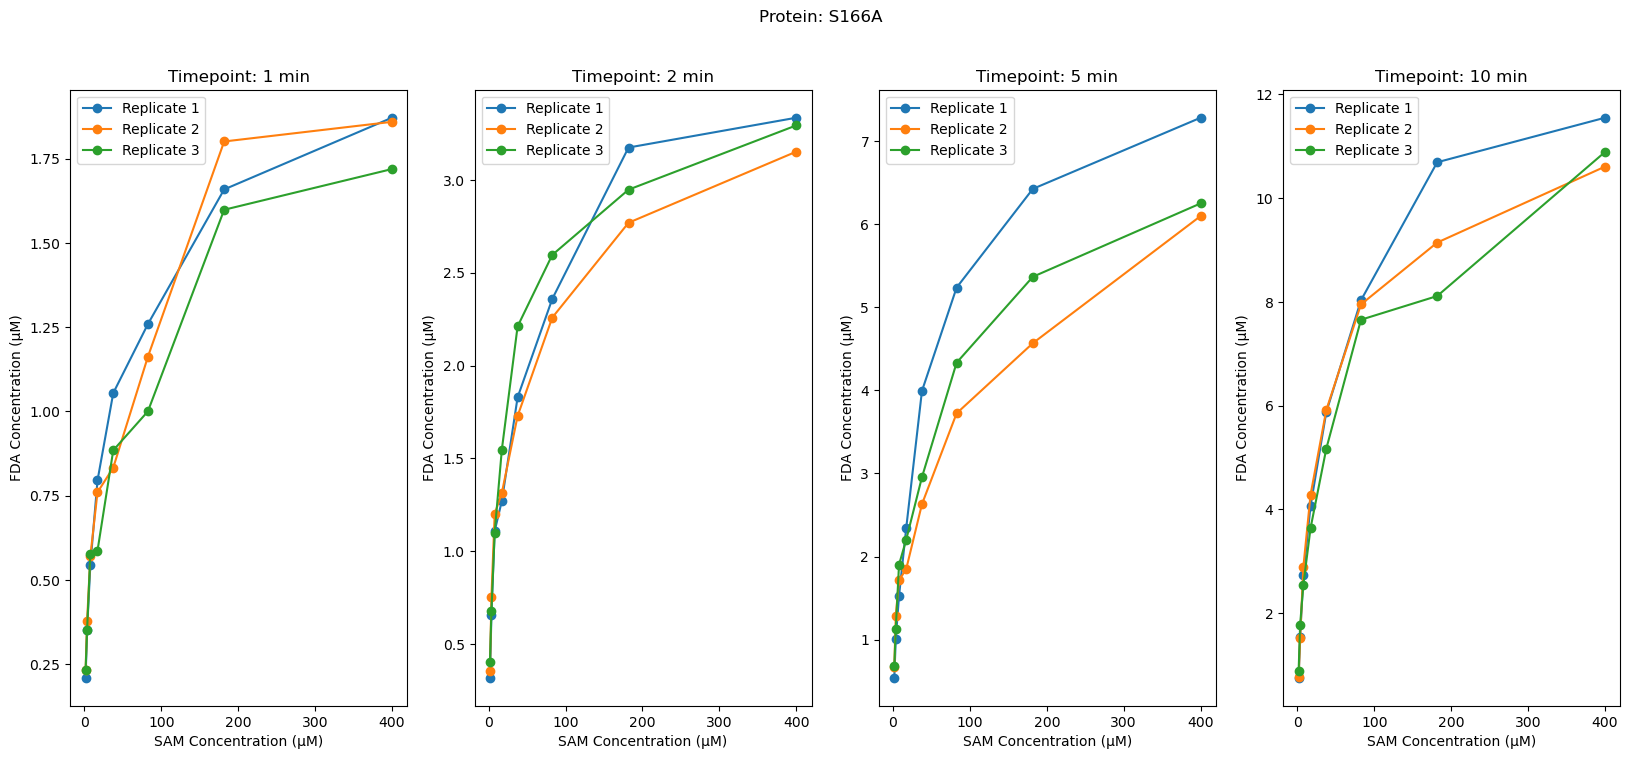

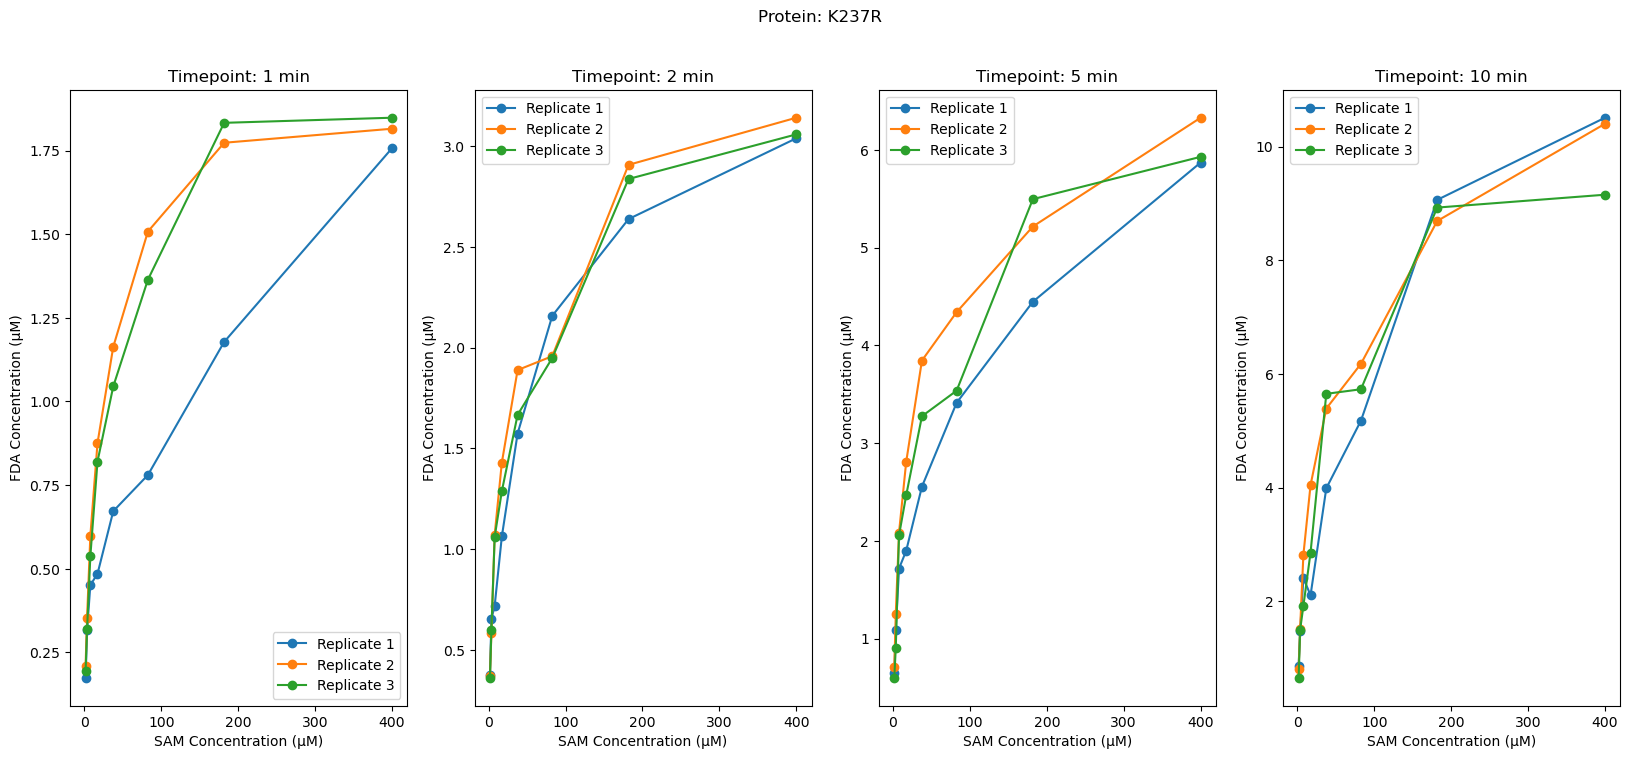

In [173]:
for prot in protein_order:
    fig,axes = plt.subplots(ncols=4, figsize=(20, 8))
    for t,ax in zip([1,2,5,10],axes):
        for rep in replicates:
            subset = data.loc[(data["Protein"]==prot) & (data["Replicate"]==rep) & (data["Timepoint"]==t)]
            ax.plot(subset["SAM Conc"], subset["FDA Conc"], 'o-',label=f'Replicate {rep}')
        ax.set_xlabel('SAM Concentration (µM)')
        ax.set_ylabel('FDA Concentration (µM)')
        ax.set_title(f'Timepoint: {t} min')
        ax.legend()
    fig.suptitle(f'Protein: {prot}')
    plt.show()

In [30]:
index = pd.MultiIndex.from_product(
    [proteins, replicates],
    names=["Protein", "Replicate"]
)

# Convert to DataFrame
kindata = index.to_frame(index=False)

kindata["Vmax"] = 0
kindata["Enzyme_conc_mean"] = [0.967855038, 0.979340973, 0.978944906, 0.965214593, 0.973399972, 0.993071286, 0.997163975, 1.002576887, 0.994919597, 0.956369103, 0.975248283, 0.994391508, 0.979737039, 0.971683683, 0.994787575, 0.978416817, 0.988714552, 0.97802075, 0.977624684, 0.974060083, 1.008517888]
kindata["Enzyme_conc_stdev"] = 0
kindata["kcat"] = 0 
kindata["Km"] = 0


In [31]:
kindata_for_bri = kindata[['Protein','Replicate','Enzyme_conc_mean']]
kindata_for_bri

,Protein,Replicate,Enzyme_conc_mean
0,H191E,1,0.967855
1,H191E,2,0.979341
2,H191E,3,0.978945
3,H32L,1,0.965215
4,H32L,2,0.973400
5,H32L,3,0.993071
6,G37D,1,0.997164
7,G37D,2,1.002577
8,G37D,3,0.994920
9,WT,1,0.956369


/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_10290/2280632812.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.2645214914937313' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Vmax"]] = Vmax_fit
/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_10290/2280632812.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '81.27716969916544' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Km"]] = Km_fit


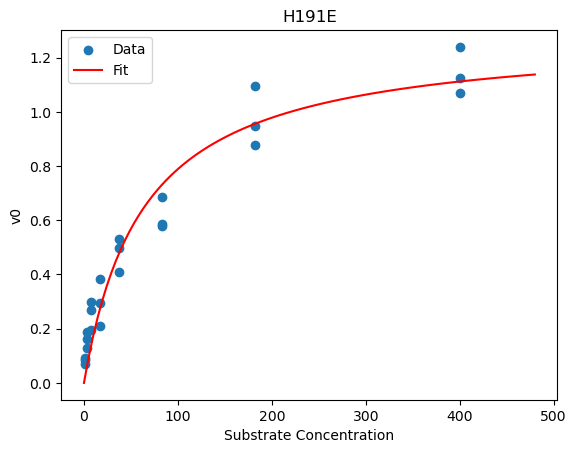

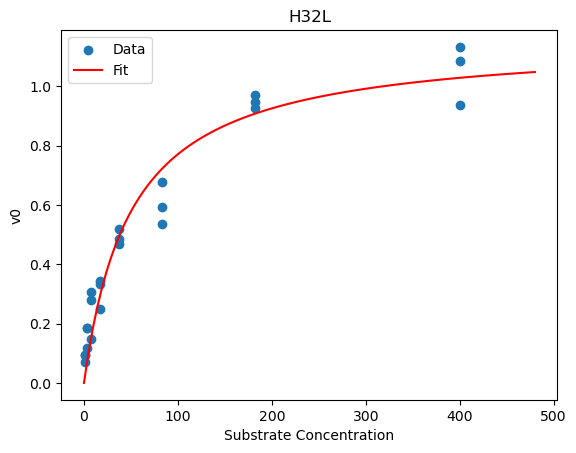

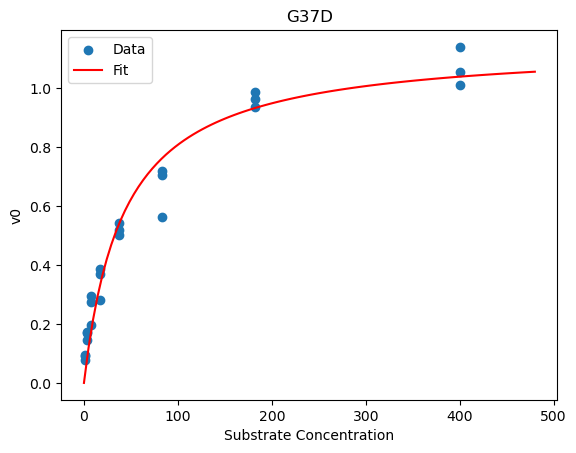

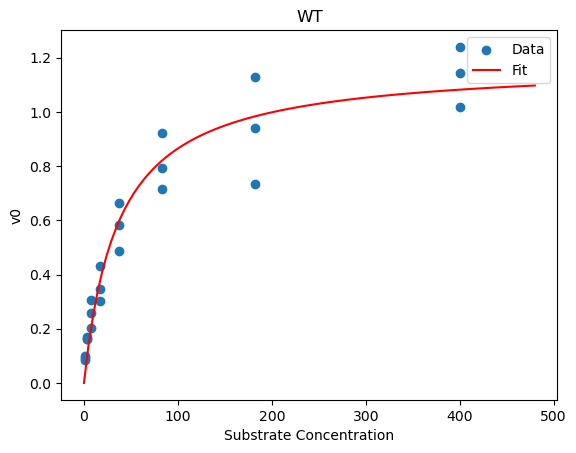

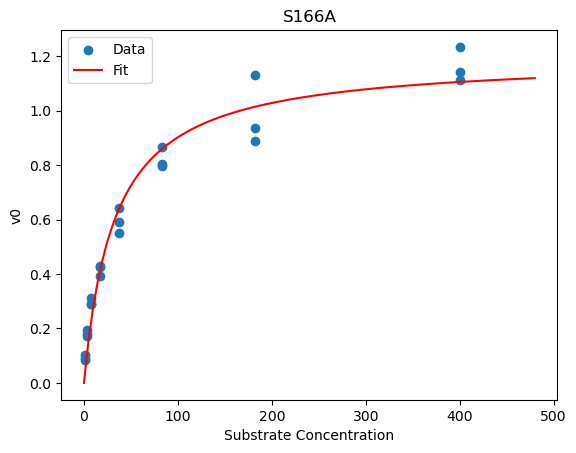

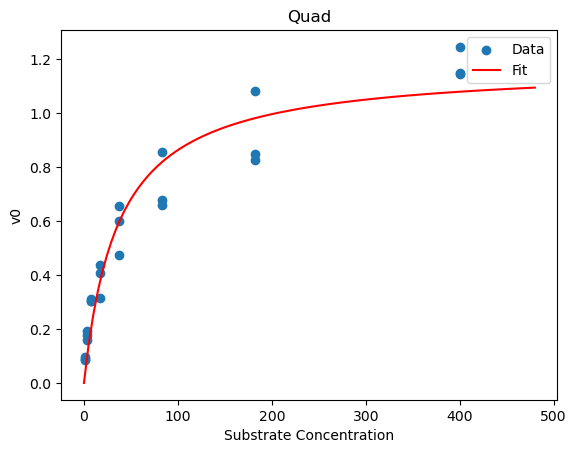

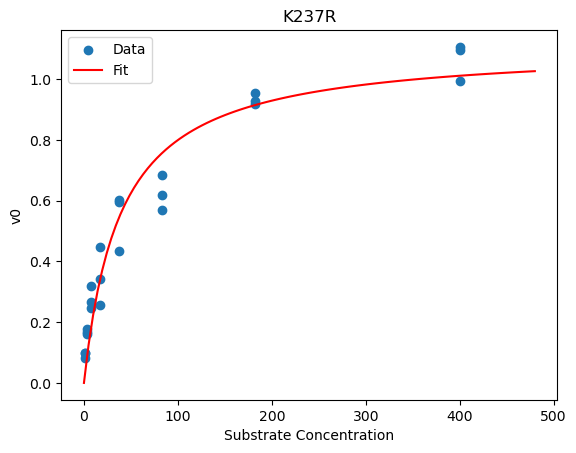

In [32]:
for prot in proteins: 
    for rep in replicates: 
            
        subset = slopes.loc[(slopes["Protein"]==prot) & (slopes["Replicate"]==rep)]
        
        S_data = np.array(subset["SAM Conc"])
        v_data = np.array(subset["v0"])
        
        popt, pcov = curve_fit(michaelis_menten, S_data, v_data, p0=[1.2, 30])
        Vmax_fit, Km_fit = popt
        
        
        kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Vmax"]] = Vmax_fit
        kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Km"]] = Km_fit
            
            
    subset = slopes.loc[(slopes["Protein"]==prot)]
    S_data = np.array(subset["SAM Conc"])
    v_data = np.array(subset["v0"])
    
    popt, pcov = curve_fit(michaelis_menten, S_data, v_data, p0=[1, 1])
    Vmax_fit, Km_fit = popt  

    S_fit = np.linspace(0, max(S_data)*1.2, 100)
    P_fit = michaelis_menten(S_fit, *popt)

    plt.scatter(S_data, v_data, label='Data')
    plt.plot(S_fit, P_fit, color='red', label='Fit')
    plt.title(prot)
    plt.xlabel('Substrate Concentration')
    plt.ylabel('v0')
    plt.legend()
    plt.show()


kindata["kcat"] = kindata["Vmax"]/(kindata["Enzyme_conc_mean"]*6)          


In [44]:
# Match the Enzyme concentrations to the correct protein and replicate in the "data" DataFrame
data_matched = pd.merge(data, kindata, on=['Protein', 'Replicate'], how='left')
#data_matched.to_csv("data/kinetics_for_Bri.csv", sep=";", index=False)
data_matched

,ID,Protein,SAM Conc,Timepoint,Replicate,FDA Area,SAM Area,Vanillin Area,Dilution,Injection,...,Area SUM,FDA Conc,FDA used,Estimated Rate,Vmax,Enzyme_conc_mean,Enzyme_conc_stdev,kcat,Km,kcat/Km
0,H191E_400_1_1,H191E,400.00,1,1,0.7827,108.8367,10.3616,1.111111,40,...,2.938719,1.601750,0.400437,1.601750,1.264521,0.967855,0,0.217753,81.27717,0.002679
1,H191E_181.82_1_1,H191E,181.82,1,1,0.5340,46.6614,9.3388,1.111111,40,...,1.403803,1.212485,0.666860,1.212485,1.264521,0.967855,0,0.217753,81.27717,0.002679
2,H191E_82.65_1_1,H191E,82.65,1,1,0.3682,20.1727,9.1456,1.111111,40,...,0.623885,0.853685,1.032892,0.853685,1.264521,0.967855,0,0.217753,81.27717,0.002679
3,H191E_37.57_1_1,H191E,37.57,1,1,0.3564,10.3016,10.2098,1.111111,40,...,0.289972,0.740196,1.970178,0.740196,1.264521,0.967855,0,0.217753,81.27717,0.002679
4,H191E_17.08_1_1,H191E,17.08,1,1,0.3036,4.7655,10.5835,1.111111,40,...,0.133045,0.608273,3.561318,0.608273,1.264521,0.967855,0,0.217753,81.27717,0.002679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,K237R_37.57_10_3,K237R,37.57,10,3,2.8808,9.7226,10.8129,1.111111,40,...,0.323775,5.649332,15.036818,0.564933,1.057536,1.008518,0,0.174767,33.36554,0.005238
668,K237R_17.08_10_3,K237R,17.08,10,3,1.4807,4.4613,10.9947,1.111111,40,...,0.150123,2.855682,16.719452,0.285568,1.057536,1.008518,0,0.174767,33.36554,0.005238
669,K237R_7.76_10_3,K237R,7.76,10,3,0.9968,1.8280,11.0364,1.111111,40,...,0.071098,1.915168,24.679996,0.191517,1.057536,1.008518,0,0.174767,33.36554,0.005238
670,K237R_3.53_10_3,K237R,3.53,10,3,0.6278,0.5263,8.8947,1.111111,40,...,0.036042,1.496636,42.397623,0.149664,1.057536,1.008518,0,0.174767,33.36554,0.005238


In [122]:
data_matched[(data_matched.Protein=='G37D')&(data_matched.Replicate==3)&(data_matched.Timepoint==1)]

,ID,Protein,SAM Conc,Timepoint,Replicate,FDA Area,SAM Area,Vanillin Area,Dilution,Injection,...,Area SUM,FDA Conc,FDA used,Estimated Rate,Vmax,Enzyme_conc_mean,Enzyme_conc_stdev,kcat,Km,kcat/Km
496,G37D_400_1_3,G37D,400.00,1,3,0.8063,101.7779,8.7324,1.111111,40,...,3.263205,1.957894,0.489474,1.957894,1.052912,0.99492,0,0.176381,34.252854,0.005149
497,G37D_181.82_1_3,G37D,181.82,1,3,0.8866,51.7928,10.1625,1.111111,40,...,1.439918,1.849922,1.017447,1.849922,1.052912,0.99492,0,0.176381,34.252854,0.005149
498,G37D_82.65_1_3,G37D,82.65,1,3,0.6548,19.7104,8.9088,1.111111,40,...,0.634990,1.558532,1.885701,1.558532,1.052912,0.99492,0,0.176381,34.252854,0.005149
499,G37D_37.57_1_3,G37D,37.57,1,3,0.4950,8.7518,8.5694,1.111111,40,...,0.299736,1.224845,3.260167,1.224845,1.052912,0.99492,0,0.176381,34.252854,0.005149
500,G37D_17.08_1_3,G37D,17.08,1,3,0.3899,4.4118,9.7970,1.111111,40,...,0.136144,0.843891,4.940814,0.843891,1.052912,0.99492,0,0.176381,34.252854,0.005149
501,G37D_7.76_1_3,G37D,7.76,1,3,0.2804,1.8970,8.9289,1.111111,40,...,0.067739,0.665896,8.581131,0.665896,1.052912,0.99492,0,0.176381,34.252854,0.005149
502,G37D_3.53_1_3,G37D,3.53,1,3,0.1919,0.8806,9.8907,1.111111,40,...,0.030121,0.411409,11.654656,0.411409,1.052912,0.99492,0,0.176381,34.252854,0.005149
503,G37D_1.6_1_3,G37D,1.60,1,3,0.0985,0.4305,10.0746,1.111111,40,...,0.014586,0.207317,12.957304,0.207317,1.052912,0.99492,0,0.176381,34.252854,0.005149


In [ ]:
data_matched[(data_matched.Protein=='G37D')&(data_matched.Replicate==3)&(data_matched.Timepoint==1)]

In [45]:
kindata.to_csv("data/kinetics_parameters.csv", sep=";", index=False)

In [46]:
kin_colors = {'WT': 'lightgrey',
    'Single': '#FFEFD3',
    'Target': '#516F84',
    'Combi': '#DF9966'}

variant_cat = {'WT':'WT',
    'S166A': 'Single',
                'Quad': 'Combi',
                'H191E': 'Single',
                'H32L': 'Single',
                'G37D': 'Single',
                'K237R': 'Target'}

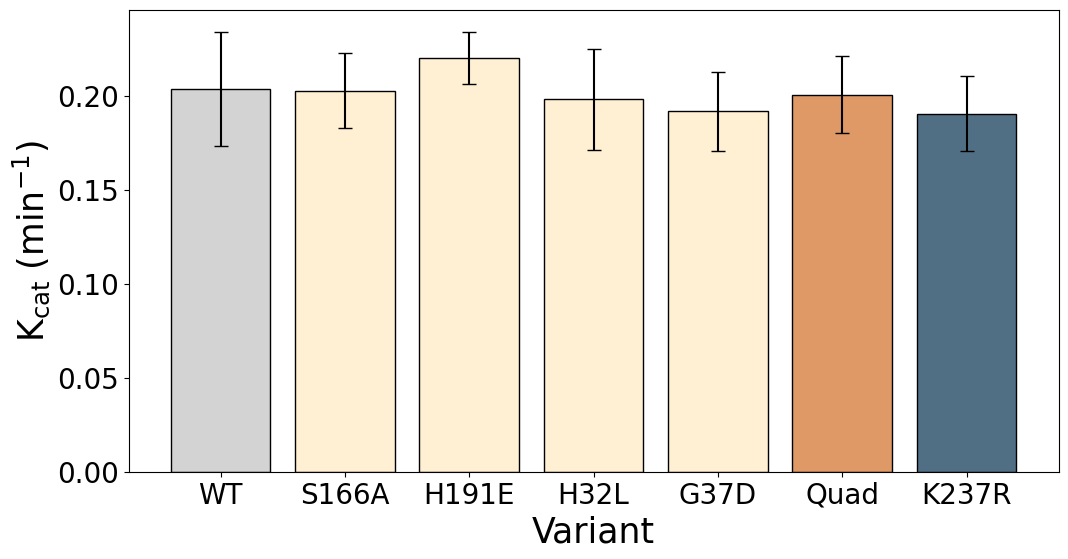

,Protein,mean,std
6,WT,0.203850,0.030378
5,S166A,0.202862,0.019902
1,H191E,0.220118,0.013940
2,H32L,0.198251,0.027011
0,G37D,0.191779,0.021172
4,Quad,0.200795,0.020669
3,K237R,0.190675,0.019895


In [33]:


# Example: Aggregating your data like in the Plotly version
kindata_kcat = kindata.groupby(by=["Protein"])["kcat"].agg(["mean", "std"]).reset_index()

# Order categories
order = ["WT", "S166A", "H191E", "H32L", "G37D", "Quad", "K237R"]
kindata_kcat["Protein"] = pd.Categorical(kindata_kcat["Protein"], categories=order, ordered=True)
kindata_kcat = kindata_kcat.sort_values("Protein")

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 6))
for prot in kindata_kcat['Protein']:
    cat = variant_cat[prot]
    ax.bar(
        prot, 
        kindata_kcat[kindata_kcat['Protein'] == prot]["mean"], 
        yerr=kindata_kcat[kindata_kcat['Protein'] == prot]["std"], 
        capsize=5,
        color=kin_colors[variant_cat[prot]],
        edgecolor="black", 
        linewidth=1.0
    )

# Labels
ax.set_xlabel("Mutants")
ax.set_ylabel("kcat")

# Styling background and axes
# ax.set_facecolor("white")
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('black')
# ax.spines['bottom'].set_color('black')

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel('Variant', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{cat}$ (min$^{-1}$)', fontsize=25)

plt.show()

kindata_kcat.head(30)


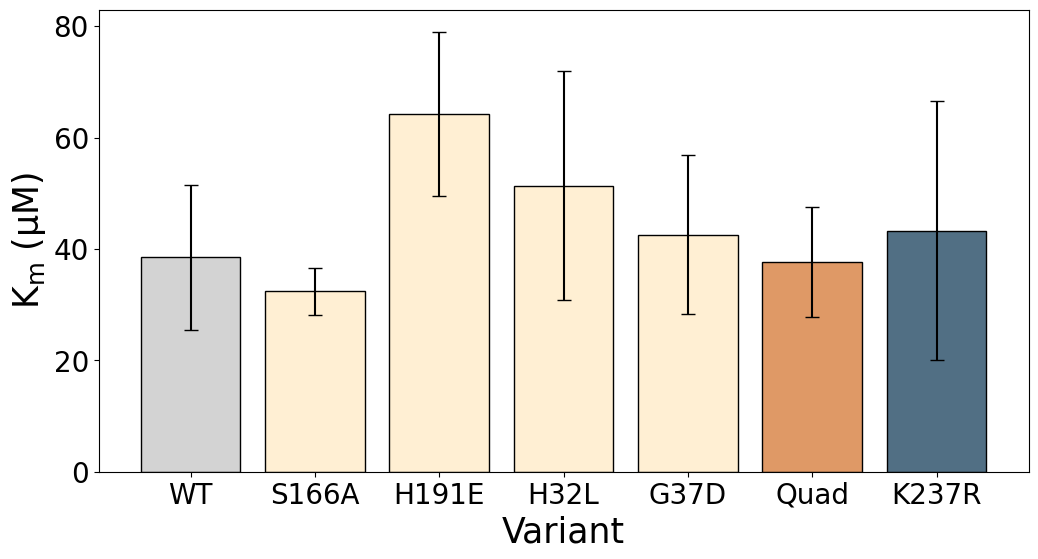

,Protein,mean,std
6,WT,38.491715,12.979276
5,S166A,32.372475,4.239113
1,H191E,64.288565,14.720214
2,H32L,51.323024,20.560755
0,G37D,42.554164,14.316174
4,Quad,37.663995,9.831706
3,K237R,43.286002,23.216156


In [34]:
# Example: Aggregating your data like in the Plotly version
kindata_km = kindata.groupby(by=["Protein"])["Km"].agg(["mean", "std"]).reset_index()

# Order categories
order = ["WT", "S166A", "H191E", "H32L", "G37D", "Quad", "K237R"]
kindata_km["Protein"] = pd.Categorical(kindata_km["Protein"], categories=order, ordered=True)
kindata_km = kindata_km.sort_values("Protein")

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 6))
for prot in kindata_km['Protein']:
    cat = variant_cat[prot]
    ax.bar(
        prot, 
        kindata_km[kindata_km['Protein'] == prot]["mean"], 
        yerr=kindata_km[kindata_km['Protein'] == prot]["std"], 
        capsize=5, 
        color=kin_colors[cat],
        edgecolor="black", 
        linewidth=1.0
    )

# Labels
ax.set_xlabel("Mutants")
ax.set_ylabel("Km")

# Styling background and axes
# ax.set_facecolor("white")
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('black')
# ax.spines['bottom'].set_color('black')

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel('Variant', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{m}$ (μM)', fontsize=25)

plt.show()

kindata_km.head(30)


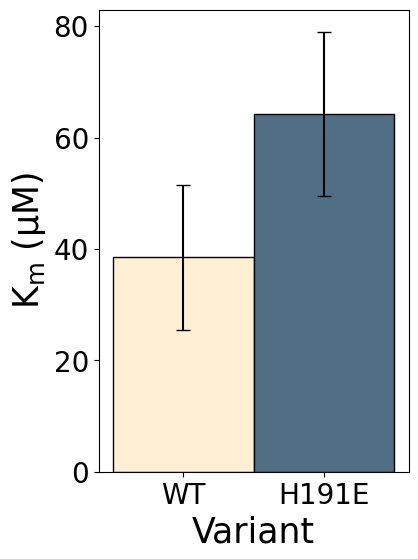

In [35]:
fig, ax = plt.subplots(figsize=(4, 6))
x = np.arange(2)
width = 1
subset_km = kindata_km[kindata_km["Protein"].isin(['WT','H191E'])]
ax.bar(
    subset_km["Protein"], 
    subset_km["mean"], 
    yerr=subset_km["std"], 
    width=width,
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0,
    color=['#FFEFD3', '#516F84']
)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel('Variant', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{m}$ (µM)', fontsize=25)
plt.show()

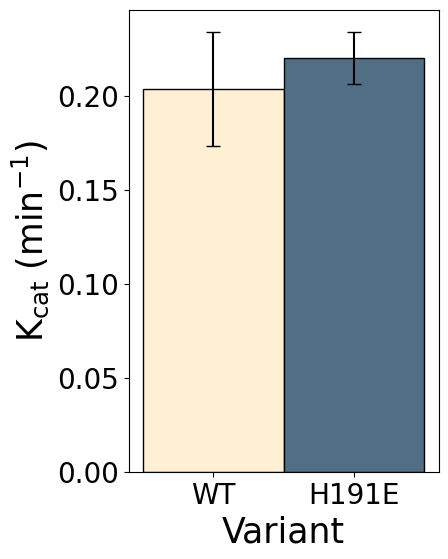

In [36]:
fig, ax = plt.subplots(figsize=(4, 6))
x = np.arange(2)
width = 1
subset_kcat = kindata_kcat[kindata_kcat["Protein"].isin(['WT','H191E'])]
ax.bar(
    subset_kcat["Protein"], 
    subset_kcat["mean"], 
    yerr=subset_kcat["std"], 
    width=width,
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0,
    color=['#FFEFD3', '#516F84']
)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel('Variant', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{cat}$ (min$^{-1}$)', fontsize=25)
plt.show()

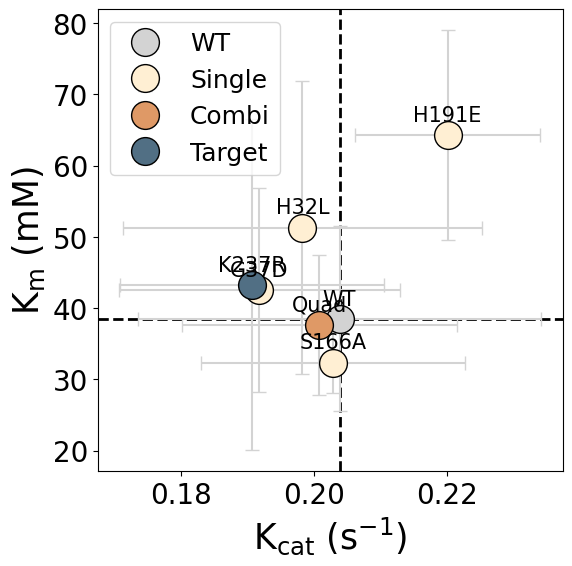

In [37]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.axvline(kindata_kcat['mean'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)
ax.axhline(kindata_km['mean'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)
#ax.scatter(exp_data_full['Kcat'].iloc[0], exp_data_full['Km'].iloc[0], s=200, color='lightgrey', edgecolor='black',zorder=2)
#ax.scatter(exp_data['Kcat'].iloc[0:7], exp_data['Km'].iloc[0:7], s=400, color=mutant_color['Single'], edgecolor='black',zorder=2,label='Rational, Single')
#ax.scatter(exp_data['Kcat'].iloc[7:9], exp_data['Km'].iloc[7:9], s=400, color=mutant_color['Double'], edgecolor='black',zorder=2,label='Rational, Double')
seen_cat = []
for prot in kindata_kcat['Protein']:
    cat = variant_cat[prot]
    ax.errorbar(
        kindata_kcat[kindata_kcat['Protein'] == prot]['mean'],
        kindata_km[kindata_km['Protein'] == prot]['mean'],
        xerr=kindata_kcat[kindata_kcat['Protein'] == prot]['std'],
        yerr=kindata_km[kindata_km['Protein'] == prot]['std'],
        fmt='o',
        color=kin_colors[variant_cat[prot]],
        ecolor='lightgrey',
        markeredgecolor='black',
        capsize=5,
        markersize=20,
        label=cat if cat not in seen_cat else None,
        zorder=2)
    seen_cat.append(cat)

    ax.annotate(
        prot,
        (kindata_kcat[kindata_kcat['Protein'] == prot]['mean'].values[0],
         kindata_km[kindata_km['Protein'] == prot]['mean'].values[0]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=15,
        color='black'
    )
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel(r'K$_\mathrm{cat}$ (s$^{-1}$)', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{m}$ (mM)', fontsize=25)
ax.legend(fontsize=18, loc='upper left')
plt.savefig('FlA_Kinetics.svg', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
kindata_grouped = kindata.groupby(by=["Protein"])

In [39]:
kindata['kcat/Km'] = kindata['kcat']/ kindata['Km']

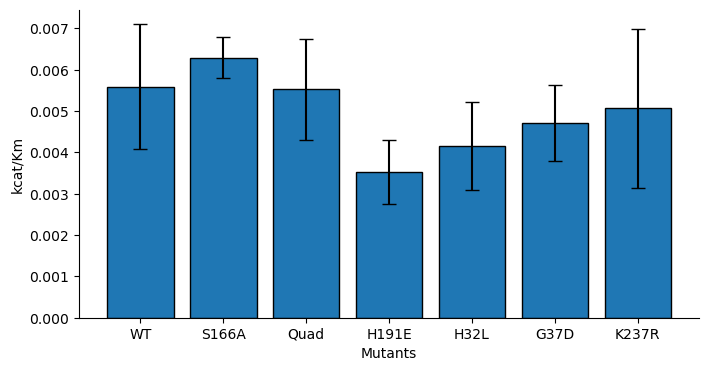

,Protein,mean,std
6,WT,38.491715,12.979276
5,S166A,32.372475,4.239113
1,H191E,64.288565,14.720214
2,H32L,51.323024,20.560755
0,G37D,42.554164,14.316174
4,Quad,37.663995,9.831706
3,K237R,43.286002,23.216156


In [40]:
# Example: Aggregating your data like in the Plotly version
kindata_cat_eff = kindata.groupby(by=["Protein"])['kcat/Km'].agg(["mean", "std"]).reset_index()

# Order categories
order = ["WT", "S166A", "Quad", "H191E", "H32L", "G37D", "K237R"]
kindata_cat_eff["Protein"] = pd.Categorical(kindata_cat_eff["Protein"], categories=order, ordered=True)
kindata_cat_eff = kindata_cat_eff.sort_values("Protein")

# Create bar plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    kindata_cat_eff["Protein"], 
    kindata_cat_eff["mean"], 
    yerr=kindata_cat_eff["std"], 
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0
)

# Labels
ax.set_xlabel("Mutants")
ax.set_ylabel("kcat/Km")

# Styling background and axes
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='out')
ax.tick_params(axis='y', which='both', left=True, right=False, direction='out')

plt.show()

kindata_km.head(30)

In [89]:
protein_order = ["WT", "H191E", "H32L", "G37D", "S166A", "K237R"]
protein_colors_dict = {
    "WT": "white",
    "H191E": "#003052",
    "H32L": "#ADB6C4",
    "G37D": "#FFEFD3",
    "S166A": "#DF9966",
    "K237R": "#E35336"
}
Tm_data = pd.read_csv("data/Tm_combined_data.csv", sep=",")
tm_mean_piv = Tm_data.pivot(index="Protein", columns="Type", values="mean").reindex(protein_order)
tm_std_piv  = Tm_data.pivot(index="Protein", columns="Type", values="std").reindex(protein_order)

In [90]:
tm_mean_piv

Type,Buffer,F-,SAM
Protein,,,
WT,57.479644,56.789372,58.103885
H191E,58.578929,58.208665,59.105013
H32L,58.465320,59.152051,59.198248
G37D,56.208404,56.926460,57.382385
S166A,56.066226,55.807317,57.663500
K237R,58.661395,58.998820,60.477515


In [91]:
kindata_cat_eff

,Protein,mean,std
6,WT,0.005594,0.001505
5,S166A,0.006297,0.000506
4,Quad,0.005529,0.001227
1,H191E,0.003536,0.000772
2,H32L,0.004147,0.001066
0,G37D,0.004712,0.000921
3,K237R,0.005065,0.001934


In [193]:
cat_eff_57 = [0.00451,0.00519,0.01393]
cat_eff_57_dict = {
    "WT": 0.00451,
    "H191E": 0.00519,
    "K237R": 0.01393
}

In [203]:
kin_data_57 = pd.read_excel("data/kinetics_parameters_57.xlsx")

In [204]:
kin_data_57

,Protein,Temp,kcat 1,kcat 2,kcat 3,km 1,km 2,km 3,kcat avg,kcat stdev,km avg,km stdev,kcat/kM 1,kcat/kM 2,kcat/kM 3,kcat/kM avg,kcat/kM stdev
0,WT,57,0.9549,1.216,1.1370,218.70,289.60,224.20,1.102633,0.133900,244.166667,39.442405,0.004366,0.004199,0.005071,0.004546,0.000463
1,H191E,57,0.9771,1.221,1.0590,193.70,257.50,176.30,1.085700,0.124123,209.166667,42.752466,0.005044,0.004742,0.006007,0.005264,0.000661
2,K237R,57,0.9049,1.019,0.8889,72.22,79.45,50.18,0.937600,0.070947,67.283333,15.246679,0.012530,0.012826,0.017714,0.014357,0.002912


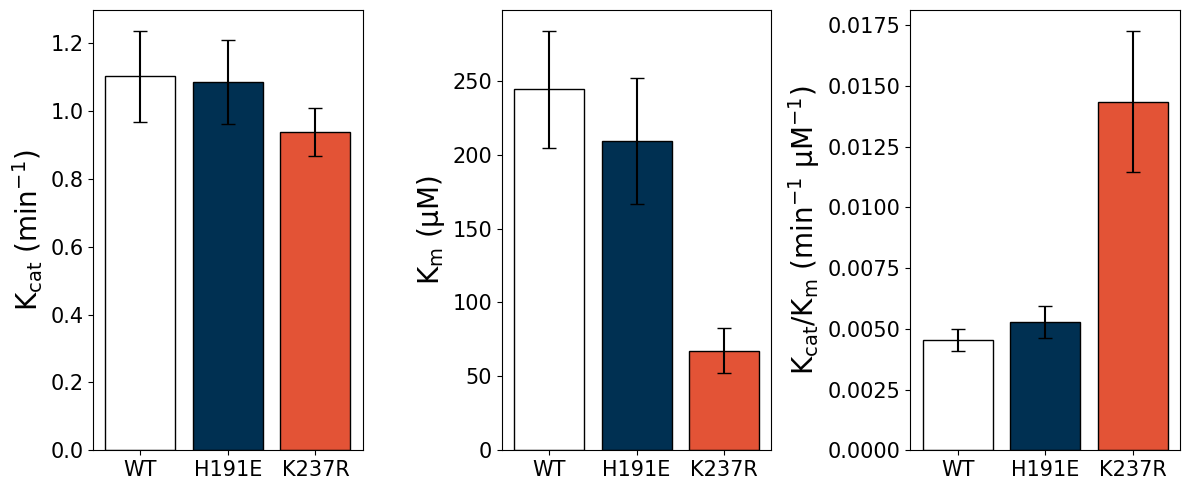

In [212]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 5))
axes[0].bar(
    kin_data_57["Protein"], 
    kin_data_57["kcat avg"], 
    yerr=kin_data_57["kcat stdev"], 
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0,
    color=[protein_colors_dict[prot] for prot in kin_data_57["Protein"]]
)
axes[1].bar(
    kin_data_57["Protein"], 
    kin_data_57["km avg"], 
    yerr=kin_data_57["km stdev"], 
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0,
    color=[protein_colors_dict[prot] for prot in kin_data_57["Protein"]]
)
axes[2].bar(
    kin_data_57["Protein"], 
    kin_data_57["kcat/kM avg"], 
    yerr=kin_data_57["kcat/kM stdev"], 
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0,
    color=[protein_colors_dict[prot] for prot in kin_data_57["Protein"]]
)
for ax, ylabel in zip(axes, [r'K$_\mathrm{cat}$ (min$^{-1}$)', r'K$_\mathrm{m}$ (µM)', r'K$_\mathrm{cat}$/K$_\mathrm{m}$ (min$^{-1}$ µM$^{-1}$)']):
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()
plt.show()

In [178]:
from matplotlib.offsetbox import DrawingArea, AnnotationBbox
from matplotlib.patches import Circle

def hatched_marker(ax, x, y, size_pts=20, hatch='///',
                   facecolor='none', edgecolor='black',
                   lw=0.0, zorder=3):
    """
    Add a hatched circular overlay at (x,y) with size in points.
    size_pts ~ diameter in points.
    """
    da = DrawingArea(size_pts, size_pts, 0, 0)
    r = size_pts / 2
    circ = Circle((r, r), r,
                  facecolor=facecolor, edgecolor=edgecolor,
                  hatch=hatch, linewidth=lw)
    da.add_artist(circ)

    ab = AnnotationBbox(da, (x, y),
                        frameon=False,
                        box_alignment=(0.5, 0.5),
                        zorder=zorder)
    ax.add_artist(ab)
    return ab


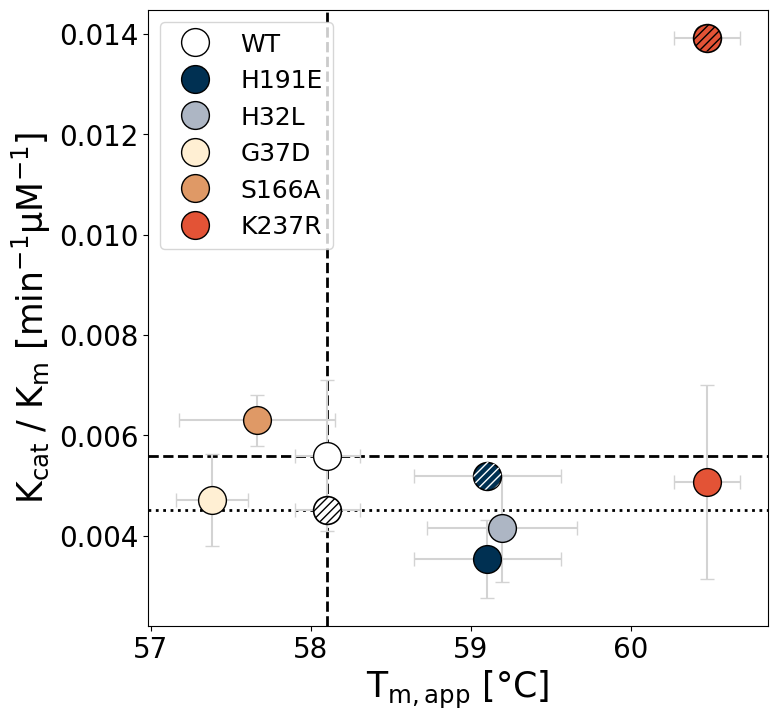

In [186]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.axhline(kindata_cat_eff['mean'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)
ax.axhline(cat_eff_57[0], color='black', linewidth=2, linestyle=':',zorder=0)
ax.axvline(tm_mean_piv['SAM'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)

from matplotlib.patches import Circle

hatch_style = "///"   # try: "/", "\\", "x", "o", ".", "*", "++", "OO"

for prot in protein_order:
    ax.errorbar(
        tm_mean_piv[tm_mean_piv.index == prot]['SAM'],
        kindata_cat_eff[kindata_cat_eff['Protein'] == prot]['mean'],
        xerr=tm_std_piv[tm_std_piv.index == prot]['SAM'],
        yerr=kindata_cat_eff[kindata_cat_eff['Protein'] == prot]['std'],
        fmt='o',
        color=protein_colors_dict[prot],
        ecolor='lightgrey',
        markeredgecolor='black',
        capsize=5,
        markersize=20,
        label=prot,
        zorder=2)

    # ax.annotate(
    #     prot,
    #     (kindata_kcat[kindata_kcat['Protein'] == prot]['mean'].values[0],
    #      kindata_km[kindata_km['Protein'] == prot]['mean'].values[0]),
    #     textcoords="offset points",
    #     xytext=(0, 10),
    #     ha='center',
    #     fontsize=15,
    #     color='black'
    # )

for i, prot in enumerate(['WT','H191E','K237R']):
    x = tm_mean_piv.loc[prot, 'SAM']
    y = cat_eff_57[i]
    xerr = tm_std_piv.loc[prot, 'SAM']

    # errorbars only
    ax.errorbar([x],[y], xerr=[xerr], fmt='none',
                ecolor='lightgrey', capsize=5, zorder=1)

    # base filled marker
    ax.scatter([x],[y], s=20**2,
               facecolors=protein_colors_dict[prot],
               edgecolors='black', linewidths=1.2, zorder=2)

    # hatched overlay (same visual size no matter axis limits)
    hatched_marker(ax, x, y, size_pts=20, hatch='////',
                   facecolor='none', edgecolor='black' if prot != 'H191E' else 'white',
                     lw=0.0, zorder=2.2)



ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel(r'T$_\mathrm{m,app}$ [°C]', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{cat}$ / K$_\mathrm{m}$ [min$^{-1}$μM$^{-1}$]', fontsize=25)
ax.legend(fontsize=18, loc='upper left')
plt.savefig('FlA_Kinetics.svg', dpi=300, bbox_inches='tight')
plt.show()

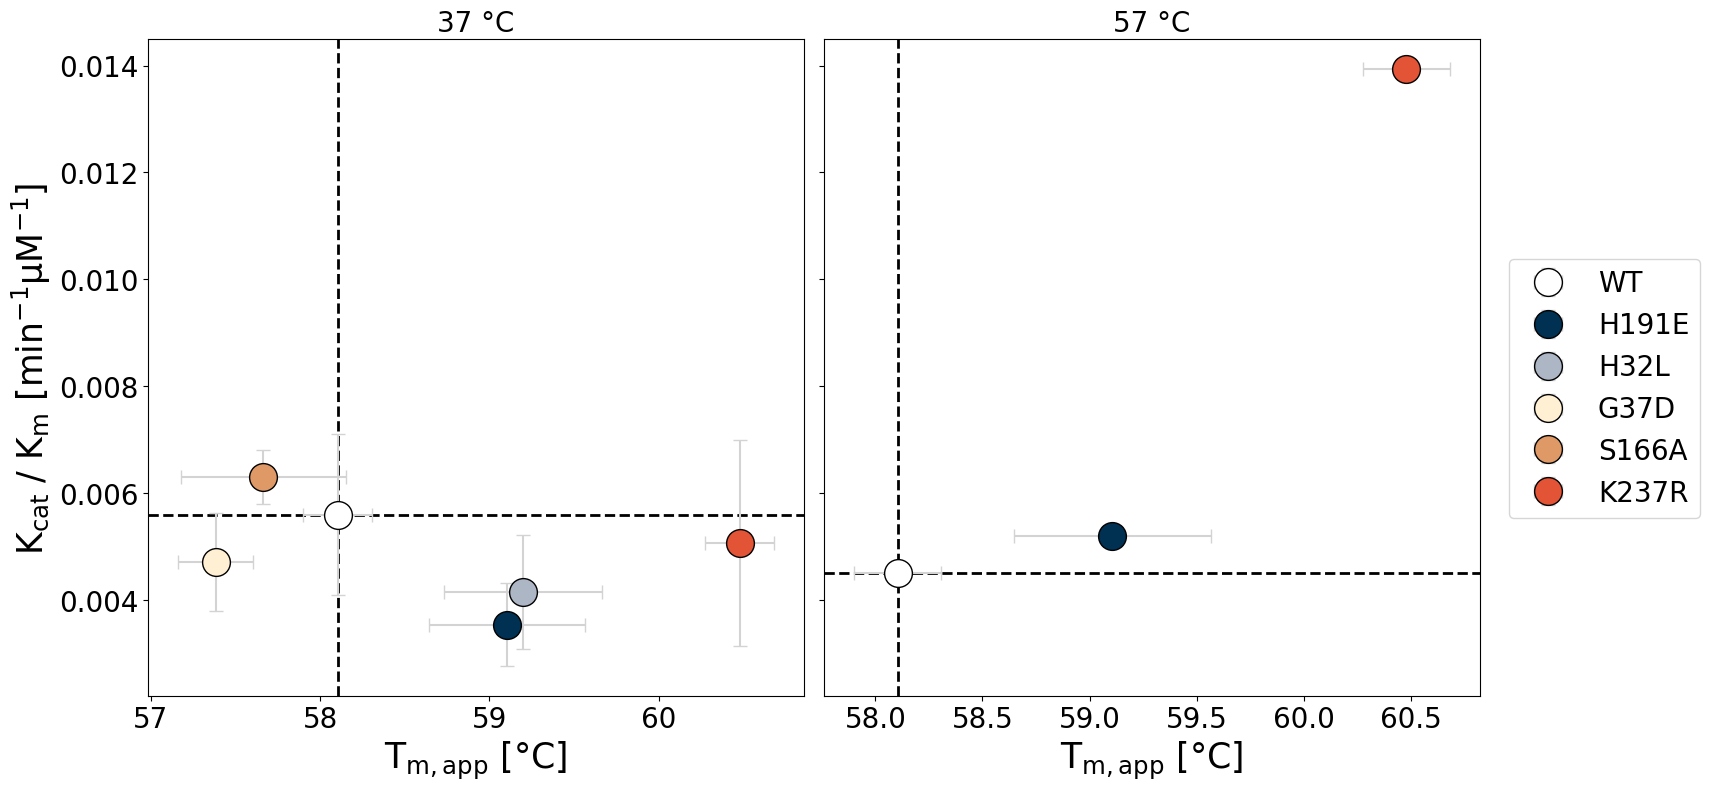

In [200]:
fig, axes = plt.subplots(ncols=2,figsize=(15, 8),sharey=True)

for prot in protein_order:
    axes[0].errorbar(
        tm_mean_piv[tm_mean_piv.index == prot]['SAM'],
        kindata_cat_eff[kindata_cat_eff['Protein'] == prot]['mean'],
        xerr=tm_std_piv[tm_std_piv.index == prot]['SAM'],
        yerr=kindata_cat_eff[kindata_cat_eff['Protein'] == prot]['std'],
        fmt='o',
        color=protein_colors_dict[prot],
        ecolor='lightgrey',
        markeredgecolor='black',
        capsize=5,
        markersize=20,
        label=prot,
        zorder=2)
    
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5),fontsize=20)
    
for prot in ['WT','H191E','K237R']:
    axes[1].errorbar(
        tm_mean_piv[tm_mean_piv.index == prot]['SAM'],
        cat_eff_57_dict[prot],
        xerr=tm_std_piv[tm_std_piv.index == prot]['SAM'],
        yerr=None,
        fmt='o',
        color=protein_colors_dict[prot],
        ecolor='lightgrey',
        markeredgecolor='black',
        capsize=5,
        markersize=20,
        label=prot,
        zorder=2)

for i in range(2):
    axes[i].axvline(tm_mean_piv['SAM'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)
    axes[i].tick_params(axis='both', which='major', labelsize=20)
    axes[i].set_xlabel(r'T$_\mathrm{m,app}$ [°C]', fontsize=25)
    #axes[i].legend(fontsize=18, loc='upper left')
    axes[i].set_box_aspect(1)

axes[0].set_ylabel(r'K$_\mathrm{cat}$ / K$_\mathrm{m}$ [min$^{-1}$μM$^{-1}$]', fontsize=25)
axes[0].axhline(kindata_cat_eff['mean'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)
axes[1].axhline(cat_eff_57[0], color='black', linewidth=2, linestyle='--',zorder=0)

axes[0].set_title('37 °C', fontsize=20)
axes[1].set_title('57 °C', fontsize=20)

plt.tight_layout()

#plt.savefig('FlA_Kinetics.svg', dpi=300, bbox_inches='tight')
plt.show()